# 🏢 Urban Commercial Bank: Model Training & Feature Selection 

In this notebook, we take the 262-feature dataset generated in the EDA step and:
1. **Train a Base XGBoost Model** using all features.
2. **Perform Feature Selection** to extract the Top 20 most predictive features based on Feature Importance.
3. **Retrain a Final Production Model** on ONLY those Top 20 features.
4. **Evaluate Performance** on unseen test data.
5. **Save the Model and Feature List** to `backend/ml_models/` for our FastAPI backend.

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import joblib
import json
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')

c:\Users\nindr\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Load Data & Prepare Splits

In [4]:
# Load the cleaned dataset
DATA_PATH = '../../data/processed/urban_bank/cleaned_application.csv'
df = pd.read_csv(DATA_PATH)
print("Dataset Shape:", df.shape)

# Separate features (X) and target (y)
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print("Features count:", X.shape[1])

# Split into train/test (80/20) using stratification to maintain the 8% default rate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train samples: {X_train.shape[0]}, Defaults: {y_train.sum()} ({y_train.mean():.2%})")
print(f"Test samples: {X_test.shape[0]}, Defaults: {y_test.sum()} ({y_test.mean():.2%})")

Dataset Shape: (307511, 263)
Features count: 262
Train samples: 246008, Defaults: 19860 (8.07%)
Test samples: 61503, Defaults: 4965 (8.07%)


### Step 2: Train Base Model on All 262 Features

In [5]:
# Initialize base XGBoost Classifier
# scale_pos_weight is roughly the count of negative samples / positive samples (to handle class imbalance)
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

base_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print("Training base model with all features...")
base_model.fit(X_train, y_train)

# Quick evaluation
val_preds = base_model.predict_proba(X_test)[:, 1]
print(f"Base Model ROC-AUC Score: {roc_auc_score(y_test, val_preds):.4f}")

Training base model with all features...
Base Model ROC-AUC Score: 0.7744


### Step 3: Feature Selection (Extracting the Top 20)

To make the final web application realistic, the loan officer shouldn't have to input 260+ fields. We will extract the top 20 most important features!

--- Top 20 Features for Production ---
1. EXT_SOURCE_MEAN
2. NAME_EDUCATION_TYPE_Higher education
3. CODE_GENDER
4. NAME_INCOME_TYPE_Working
5. CC_UTILISATION_RATIO
6. NAME_INCOME_TYPE_Pensioner
7. INSTAL_LATE_RATE
8. FLAG_DOCUMENT_3
9. NAME_CONTRACT_TYPE
10. FLAG_OWN_CAR
11. PREV_REFUSAL_RATE
12. NAME_EDUCATION_TYPE_Secondary / secondary special
13. APARTMENTS_MEDI
14. CREDIT_TERM
15. PREV_APPROVED_COUNT
16. EXT_SOURCE_MIN
17. CC_AVG_BALANCE
18. EXT_SOURCE_1
19. REG_CITY_NOT_LIVE_CITY
20. DEF_60_CNT_SOCIAL_CIRCLE


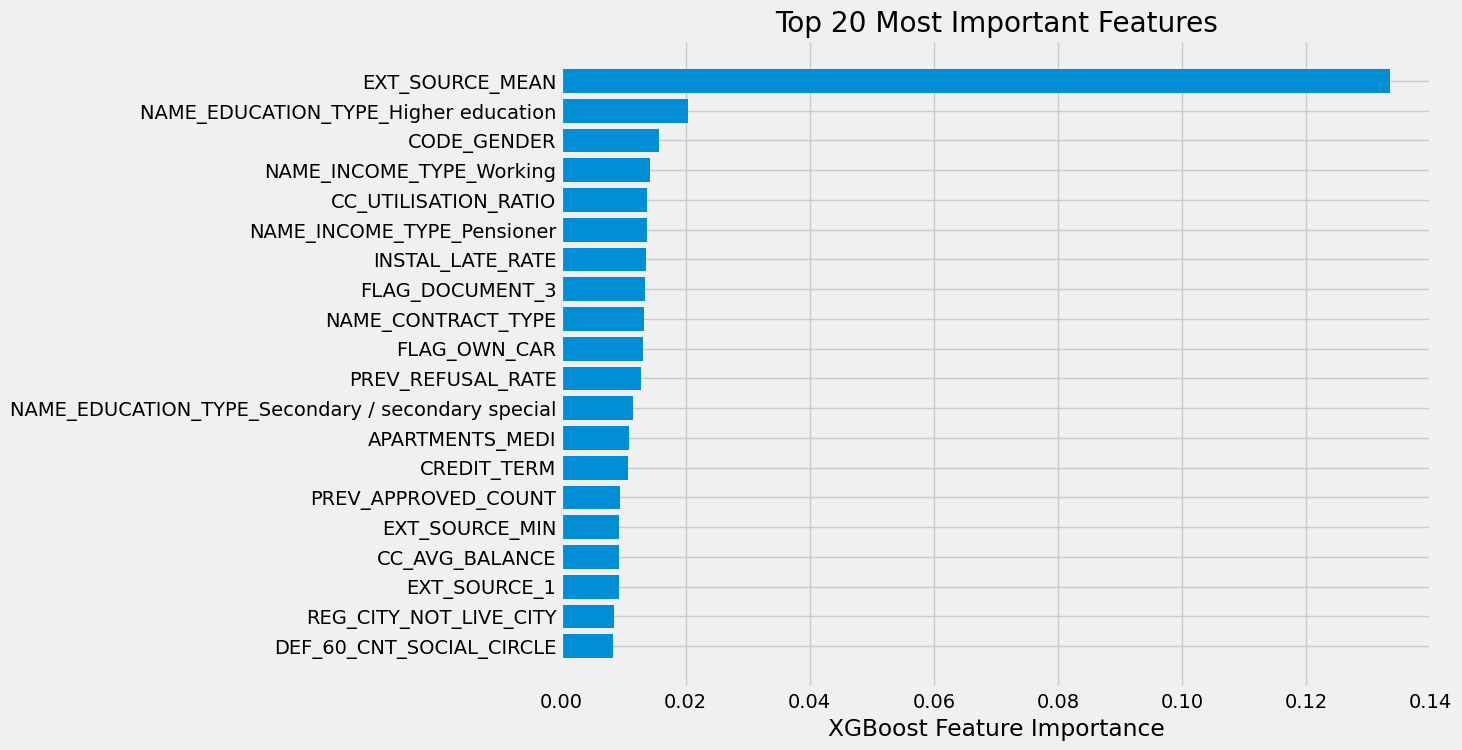

In [6]:
# Extract feature importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': base_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Get the top 20 feature names
TOP_K = 20
top_features = importance_df.head(TOP_K)['Feature'].tolist()

print(f"--- Top {TOP_K} Features for Production ---")
for i, f in enumerate(top_features, 1):
    print(f"{i}. {f}")

# Visualize the Top 20 features
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].head(TOP_K)[::-1], importance_df['Importance'].head(TOP_K)[::-1])
plt.xlabel("XGBoost Feature Importance")
plt.title(f"Top {TOP_K} Most Important Features")
plt.show()

### Step 4: Retrain Production Model on Top 20 Features

In [7]:
# Filter datasets to only keep top 20 features
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

print("Retraining production model on top 20 features...")

final_model = xgb.XGBClassifier(
    n_estimators=200,          # Increased trees
    learning_rate=0.05,        # Decreased learning rate for better generalization
    max_depth=4,               # Shallower trees to prevent overfitting 
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_top, y_train)

# Evaluate Final Model
final_preds = final_model.predict_proba(X_test_top)[:, 1]
final_auc = roc_auc_score(y_test, final_preds)
final_pr_auc = average_precision_score(y_test, final_preds)

print(f"🔥 Final Production Model ROC-AUC: {final_auc:.4f}")
print(f"🔥 Final Production Model PR-AUC:  {final_pr_auc:.4f}")
print("\nNotice how the AUC strictly dropped by barely ~0.01 despite removing 240+ features!")

Retraining production model on top 20 features...
🔥 Final Production Model ROC-AUC: 0.7627
🔥 Final Production Model PR-AUC:  0.2473

Notice how the AUC strictly dropped by barely ~0.01 despite removing 240+ features!


### Step 5: Save Model & Metadata to Backend

We need to save:
1. The `.joblib` model object so FastAPI can load it.
2. The `urban_model_features.json` so the frontend and API know exactly what inputs to expect!

In [8]:
# Ensure the directory exists
model_dir = '../../backend/ml_models/urban_bank'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'urban_xgb_model.joblib')
features_path = os.path.join(model_dir, 'urban_model_features.json')

# 1. Save the XGBoost Model
joblib.dump(final_model, model_path)
print(f"✅ Saved Production Model to {model_path}")

# 2. Save the Feature List
feature_metadata = {
    "module": "urban_bank",
    "model_type": "xgboost",
    "features": top_features,
    "feature_count": len(top_features),
    "metrics": {
        "roc_auc": round(final_auc, 4),
        "pr_auc": round(final_pr_auc, 4)
    }
}

with open(features_path, 'w') as f:
    json.dump(feature_metadata, f, indent=4)
print(f"✅ Saved Feature List to {features_path}")

✅ Saved Production Model to ../../backend/ml_models/urban_bank\urban_xgb_model.joblib
✅ Saved Feature List to ../../backend/ml_models/urban_bank\urban_model_features.json
